# 第 8 章　因果推断进阶
## DID、PSM、RDD 与 DDML

::: {.callout-note}
## 本章要点

1. **DID**：2×2 基础 → 事件研究型 DID → 多期 DID（Callaway-Sant'Anna 直觉）
2. **平行趋势检验**：Pre-trend test 的实现与解读
3. **PSM**：倾向得分匹配 + 共同支撑检验
4. **RDD**：精确 RDD、带宽选择直觉、模糊 RDD 简介
5. **DDML**：高维控制变量下的因果估计（`doubleml` 库）

**与前几章的连接**：
DID = 第 6 章 TWFE 的直接延伸（处理变量 × 时间虚拟变量的交乘项）；
DDML = 第 5 章 FWL 定理的机器学习版本。
理解了这两个连接，本章的所有方法都是已知工具的延伸，不是新工具。
:::


## 环境准备


In [ ]:
%pip install pyfixest

In [3]:
# ── 第 8 章　因果推断进阶　─────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import pyfixest as pf
from scipy import stats
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, KFold

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_CLEAN = 'data_clean'
OUTPUT     = 'output'
for d in [DATA_CLEAN, OUTPUT]:
    os.makedirs(d, exist_ok=True)

RNG = np.random.default_rng(42)
print('环境就绪 ✓')


环境就绪 ✓


---

## 1　本章演示数据

本章用三个独立的模拟场景，分别对应 DID、PSM、RDD 三种方法。
每个场景的 DGP 都是已知的，方便验证估计量的正确性。

**贯穿案例**：评估某省「绿色信贷政策」（2019 年实施）
对重污染行业上市公司借款利率的影响。


### 1.1　DID 场景：事件研究型 DID

下面，我们采用 Monte Carlo 模拟数据，构建一个事件研究型 DID 场景。数据生成过程如下：

- 观察期为 2015-2022 年，共 8 年。其中，2019 年为政策实施年。
- 共有 500 家上市公司，即 $N = 500$。
    - 处理组：$N_1 \approx 200$，我们从 $N$ 中以 40% 的概率随机抽取公司作为处理组，即 $\text{Treated}_i \sim \text{Bernoulli}(0.4)$。
    - 对照组：$N_0 \approx 300$，剩余公司作为对照组。

结果变量（借款利率 $Y_{it}$）的 DGP 设定如下：

$$Y_{it} = 5.0 + \alpha_i + \lambda_t - 0.3 \cdot \text{Size}_{it} + 0.8 \cdot \text{Lev}_{it} + \beta \cdot D_{it} + \epsilon_{it}$$

其中：

- $\alpha_i$：公司固定效应，模拟为 $\alpha_i \sim \mathcal{N}(0, 0.5)$，捕捉公司层面不随时间变化的异质性（如信用资质、所有制性质）。
- $\lambda_t$：年份固定效应，模拟为 $\lambda_t \sim \mathcal{N}(0, 0.2)$，捕捉宏观经济周期、货币政策等共同时间趋势。
- $\text{Size}_{it}$：企业规模（总资产对数），模拟为公司层面均值 $\sim \mathcal{N}(23, 1.5)$，加时变扰动 $\sim \mathcal{N}(0, 0.2)$；系数为 $-0.3$，规模越大借款利率越低。
- $\text{Lev}_{it}$：资产负债率，模拟为公司层面均值 $\sim \text{Beta}(2, 5)$，加时变扰动 $\sim \mathcal{N}(0, 0.03)$，截断至 $[0.05, 0.95]$；系数为 $+0.8$，杠杆越高利率越高。
- $D_{it}$：处理哑变量，定义为

$$D_{it} = \text{Treated}_i \times \mathbf{1}[t \geq 2019]$$

即仅处理组在政策实施年（2019 年）及之后取值为 1，其余均为 0。

- $\beta = 0.5$：**真实 ATT（平均处理效应）**，表示政策使处理组借款利率上升 0.5 个百分点。
- $\epsilon_{it}$：特异性扰动项，$\epsilon_{it} \sim \mathcal{N}(0, 0.3)$，独立同分布。

In [17]:
# ── 1.1  DID 场景数据（修正 DGP，确保借款利率在 0.03-0.12 之间）────────
N_FIRMS = 500
YEARS   = list(range(2015, 2023))
TREAT_YEAR = 2019
TRUE_ATT   = 0.02   # 政策使利率上升约 2 个百分点（0.02）

n = N_FIRMS * len(YEARS)
firm_id = np.repeat(np.arange(N_FIRMS), len(YEARS))
year_id = np.tile(YEARS, N_FIRMS)

treated_firm = RNG.binomial(1, 0.4, N_FIRMS)
treated      = np.repeat(treated_firm, len(YEARS))
post         = (year_id >= TREAT_YEAR).astype(int)
did_dummy    = treated * post

firm_fe  = RNG.normal(0, 0.005, N_FIRMS)           # 公司固定效应，波动缩小
year_fe  = {y: v for y, v in zip(YEARS, RNG.normal(0, 0.003, len(YEARS)))}

# Size_w：标准化后用于控制，不直接影响利率水平
Size_w = (np.repeat(RNG.normal(23, 1.5, N_FIRMS), len(YEARS))
          + RNG.normal(0, 0.2, n))
# 中心化 Size_w，避免截距被拉偏
Size_w_c = Size_w - 23.0

Lev_w  = np.clip(
    np.repeat(RNG.beta(2, 5, N_FIRMS), len(YEARS)) + RNG.normal(0, 0.03, n),
    0.05, 0.95)

eps  = RNG.normal(0, 0.005, n)

# DGP：截距设为 0.065（约为利率中枢），系数缩放以保持利率在合理范围
rate = (0.065
        + np.repeat(firm_fe, len(YEARS))
        + np.array([year_fe[y] for y in year_id])
        - 0.003 * Size_w_c      # 规模越大，利率略低
        + 0.04  * Lev_w         # 杠杆越高，利率略高
        + TRUE_ATT * did_dummy
        + eps)

df_did = pd.DataFrame({
    'firm'   : pd.Series(firm_id).astype(str).str.zfill(4),
    'year'   : year_id,
    'treated': treated.astype(int),
    'post'   : post.astype(int),
    'did'    : did_dummy.astype(int),
    'rate'   : rate,
    'Size_w' : Size_w,
    'Lev_w'  : Lev_w,
})

print(f'DID 数据：{df_did.shape}  处理组公司：{treated_firm.sum()}  真实 ATT = {TRUE_ATT}')
print(f'借款利率范围：[{rate.min():.4f}, {rate.max():.4f}]，均值：{rate.mean():.4f}')

DID 数据：(4000, 8)  处理组公司：205  真实 ATT = 0.02
借款利率范围：[0.0430, 0.1246]，均值：0.0792


::: {.callout-tip}

### 提示词

根据上一个代码块的内容，帮我补充如下文字，要写清楚数据生成过程，包含数学公式和解释

```md
### 1.1　DID 场景：事件研究型 DID

下面，我们采用 Monte Carlo 模拟数据，构建一个事件研究型 DID 场景。数据生成过程如下：

- 观察期为 2015-2023 年，共 9 年。……
```
:::

::: {.callout-tip}
### 提示词

```md
DID 数据已经生成，请做一些基本的数据概览和描述性统计分析，以便读者了解数据的结构和特征。可以包括以下内容：

1. 数据维度：总观测数、公司数量、年份数量。在一行内呈现这些信息，只需呈现公司数即可，无需呈现占比。
2. 处理组和对照组的公司数量分布。在一行里呈现这些信息。
3. 结果变量（借款利率）的核密度函数图：并排两个，一个是事前的，一个是事后的；每个图中都包含两条曲线（处理组和对照组）。
4. 处理组和对照组的结果变量的均值比较，做成一个 2*2 表格，显示政策前后的均值。另外新增一行和一列，显示两组的差值（Diff）。所有数值，小数点后保留两位即可。
5. 时序图：展示处理组和对照组的借款利率均值随时间变化的趋势，以及两组差值（Diff）的时序图。
```

【数据维度】总观测数 = 4000，公司数量 = 500，年份数量 = 8

【处理组与对照组】对照组 = 295 家，处理组 = 205 家



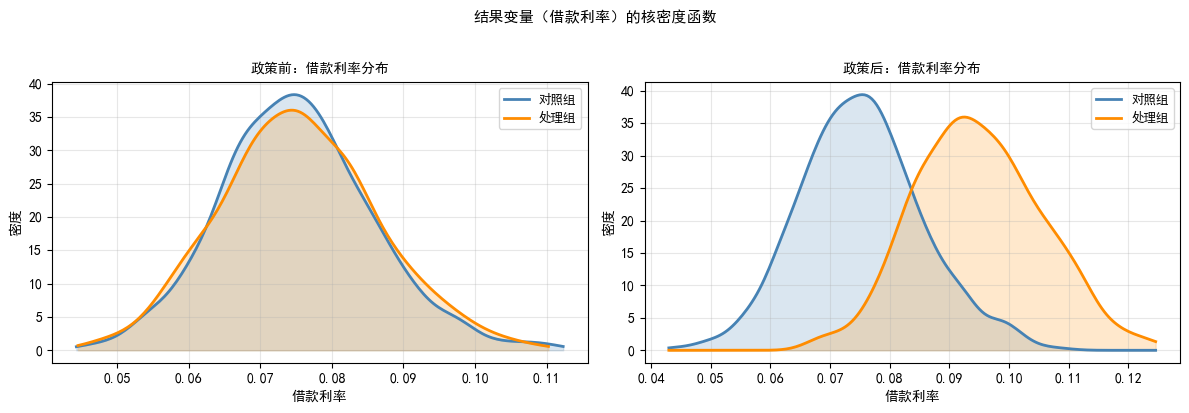


【处理组 vs 对照组：借款利率均值对比（政策前后）】
        政策前    政策后   Diff
对照组  0.0800 0.0800 0.0000
处理组  0.0800 0.0900 0.0200
Diff 0.0000 0.0200 0.0200



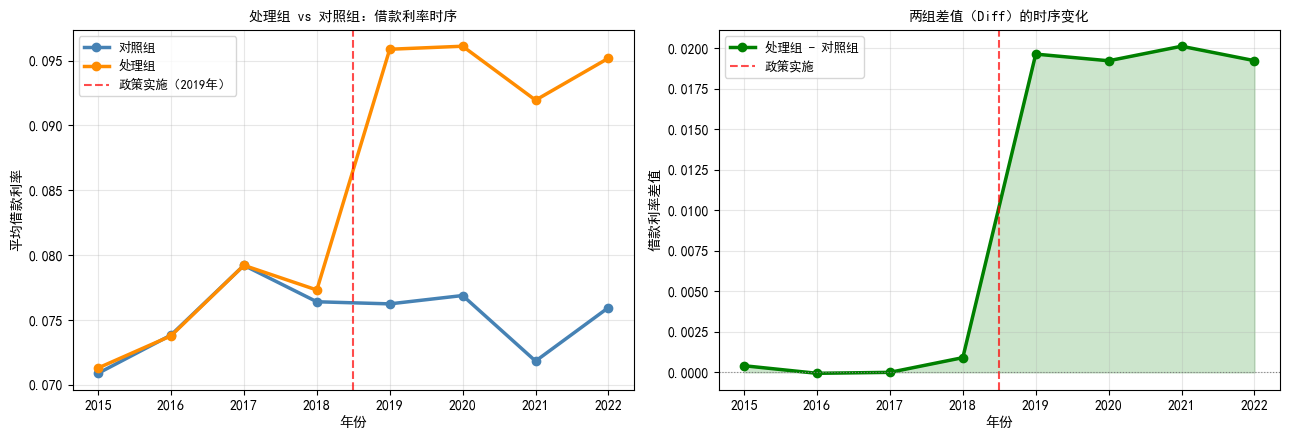

In [18]:
from scipy import stats

# ── 1.2  DID 数据概览与描述性统计 ───────────────────────────────────────

# 1. 数据维度（一行呈现）
print(f'【数据维度】总观测数 = {len(df_did)}，公司数量 = {df_did["firm"].nunique()}，年份数量 = {df_did["year"].nunique()}')
print()

# 2. 处理组与对照组公司数量分布（一行呈现）
treat_counts_val = df_did.drop_duplicates('firm').groupby('treated').size()
print(f'【处理组与对照组】对照组 = {treat_counts_val[0]} 家，处理组 = {treat_counts_val[1]} 家')
print()

# 3. 核密度函数图：事前 vs 事后

pre_data  = df_did[df_did['year'] < TREAT_YEAR]
post_data = df_did[df_did['year'] >= TREAT_YEAR]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 事前（政策前）
for treated_val, color, label in [(0, 'steelblue', '对照组'), (1, 'darkorange', '处理组')]:
	data = pre_data[pre_data['treated'] == treated_val]['rate']
	density = stats.gaussian_kde(data)
	xs = np.linspace(data.min(), data.max(), 200)
	ax1.plot(xs, density(xs), linewidth=2, color=color, label=label)
	ax1.fill_between(xs, density(xs), alpha=0.2, color=color)

ax1.set_xlabel('借款利率', fontsize=10)
ax1.set_ylabel('密度', fontsize=10)
ax1.set_title('政策前：借款利率分布', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# 事后（政策后）
for treated_val, color, label in [(0, 'steelblue', '对照组'), (1, 'darkorange', '处理组')]:
	data = post_data[post_data['treated'] == treated_val]['rate']
	density = stats.gaussian_kde(data)
	xs = np.linspace(post_data['rate'].min(), post_data['rate'].max(), 200)
	ax2.plot(xs, density(xs), linewidth=2, color=color, label=label)
	ax2.fill_between(xs, density(xs), alpha=0.2, color=color)

ax2.set_xlabel('借款利率', fontsize=10)
ax2.set_ylabel('密度', fontsize=10)
ax2.set_title('政策后：借款利率分布', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('结果变量（借款利率）的核密度函数', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/ch08_did_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print()

# 4. 均值比较表：政策前后 × 处理组 vs 对照组
mean_tbl = df_did.groupby(['treated', 'post'])['rate'].mean().unstack()
mean_tbl.index = ['对照组', '处理组']
mean_tbl.columns = ['政策前', '政策后']

# 新增行：差值（政策后 - 政策前）
mean_tbl['Diff'] = mean_tbl['政策后'] - mean_tbl['政策前']

# 新增列：两组差值
mean_tbl.loc['Diff'] = mean_tbl.loc['处理组'] - mean_tbl.loc['对照组']

print('【处理组 vs 对照组：借款利率均值对比（政策前后）】')
print(mean_tbl.round(2).to_string())
print()

# 5. 时序图：两组均值随时间变化 + 差值
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# 左图：处理组和对照组的时序图
ts_mean = df_did.groupby(['year', 'treated'])['rate'].mean().unstack()
ts_mean.columns = ['对照组', '处理组']

ax1.plot(ts_mean.index, ts_mean['对照组'], 'o-', linewidth=2.5, markersize=6,
		 color='steelblue', label='对照组')
ax1.plot(ts_mean.index, ts_mean['处理组'], 'o-', linewidth=2.5, markersize=6,
		 color='darkorange', label='处理组')
ax1.axvline(TREAT_YEAR - 0.5, color='red', linewidth=1.5, linestyle='--',
			label='政策实施（2019年）', alpha=0.7)
ax1.set_xlabel('年份', fontsize=10)
ax1.set_ylabel('平均借款利率', fontsize=10)
ax1.set_title('处理组 vs 对照组：借款利率时序', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# 右图：两组差值的时序图
ts_diff = ts_mean['处理组'] - ts_mean['对照组']
ax2.plot(ts_diff.index, ts_diff.values, 'o-', linewidth=2.5, markersize=6,
		 color='green', label='处理组 - 对照组')
ax2.axvline(TREAT_YEAR - 0.5, color='red', linewidth=1.5, linestyle='--',
			label='政策实施', alpha=0.7)
ax2.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax2.fill_between(ts_diff.index, 0, ts_diff.values, alpha=0.2, color='green')
ax2.set_xlabel('年份', fontsize=10)
ax2.set_ylabel('借款利率差值', fontsize=10)
ax2.set_title('两组差值（Diff）的时序变化', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/ch08_did_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 2　双重差分法（DID）

### 2.1　从 TWFE 到 DID：一步之差

第 6 章的双向固定效应（TWFE）回归：

$$Y_{it} = \alpha_i + \lambda_t + \varepsilon_{it}$$

DID 只是在 TWFE 的基础上，**加入一个处理哑变量 × 时间哑变量的交乘项**：

$$Y_{it} = \alpha_i + \lambda_t + \delta \cdot (\text{Treated}_i \times \text{Post}_t) + X_{it}'\beta + \varepsilon_{it}$$

其中 $\hat{\delta}$ 就是 DID 估计量——**处理组相对于控制组，
在政策实施后相对于政策实施前的额外变化**。

### 2.2　2×2 DID 的直觉

$$\hat{\delta}_{DID} = \underbrace{(\bar{Y}_{treat,post} - \bar{Y}_{treat,pre})}_{\text{处理组前后变化}}
- \underbrace{(\bar{Y}_{ctrl,post} - \bar{Y}_{ctrl,pre})}_{\text{控制组前后变化}}$$

控制组的变化扮演了「反事实」的角色：
在没有政策的情况下，处理组本来会怎么变化？

::: {.callout-important}

## 平行趋势假设（Parallel Trends Assumption）

DID 的核心识别假设：**如果没有政策干预，处理组和控制组的结果变量会以相同的趋势变化**。

这个假设**不可直接检验**（因为观察不到处理组在处理后的反事实）。但可以用**预处理期的平行趋势**来间接支持它：如果处理前两组趋势已经不平行，处理后更难说是平行的。
:::


In [19]:
# ── 2.3  2×2 DID：手动计算 + 回归验证 ──────────────────────────────────

# 手动计算（政策实施年份前后各取均值）
pre  = df_did[df_did['year'] < TREAT_YEAR]
post = df_did[df_did['year'] >= TREAT_YEAR]

mean = df_did.groupby(['treated','post'])['rate'].mean().unstack()
print('2×2 均值表：')
print(mean.rename(index={0:'控制组',1:'处理组'},
                  columns={0:'政策前',1:'政策后'}).round(4).to_string())

did_manual = (mean.loc[1,1] - mean.loc[1,0]) - (mean.loc[0,1] - mean.loc[0,0])
print(f'\n手动 DID = {did_manual:.4f}')

# 回归验证
m_did = pf.feols('rate ~ did | firm + year', data=df_did,
                  vcov={'CRV1': 'firm'})
print(f'回归 DID（TWFE）= {m_did.coef()["did"]:.4f}')
print(f'真实 ATT        = {TRUE_ATT:.4f}')


2×2 均值表：
post       政策前    政策后
treated              
控制组     0.0751 0.0752
处理组     0.0754 0.0948

手动 DID = 0.0192
回归 DID（TWFE）= 0.0192
真实 ATT        = 0.0200


In [20]:
# ── 2.4  事件研究型 DID（Dynamic DID）────────────────────────────────────
# 把 did 哑变量替换为每个相对年份的哑变量，观察政策效应的动态变化
# 同时可用于平行趋势检验（政策前各年系数应不显著）

df_did['year_rel'] = df_did['year'] - TREAT_YEAR

# 创建相对年份哑变量（基准期 = -1，即政策前一年）
year_rels = sorted(df_did['year_rel'].unique())
for yr in year_rels:
    if yr != -1:  # -1 为基准期（omitted）
        df_did[f'yr_{yr:+d}'.replace('+','p').replace('-','m')] = (
            (df_did['treated'] == 1) & (df_did['year_rel'] == yr)).astype(int)

yr_dummies = [f'yr_{yr:+d}'.replace('+','p').replace('-','m')
              for yr in year_rels if yr != -1]

formula_dyn = 'rate ~ ' + ' + '.join(yr_dummies) + ' | firm + year'
m_dyn = pf.feols(formula_dyn, data=df_did, vcov={'CRV1': 'firm'})

# 整理系数
coef_dyn = []
for yr in year_rels:
    if yr == -1:
        coef_dyn.append({'year_rel': yr, 'coef': 0, 'ci_lo': 0, 'ci_hi': 0})
    else:
        vname = f'yr_{yr:+d}'.replace('+','p').replace('-','m')
        if vname in m_dyn.coef().index:
            c  = m_dyn.coef()[vname]
            se = m_dyn.se()[vname]
            coef_dyn.append({
                'year_rel': yr, 'coef': c,
                'ci_lo': c - 1.96*se, 'ci_hi': c + 1.96*se
            })

coef_df = pd.DataFrame(coef_dyn).sort_values('year_rel')
print('动态 DID 系数：')
print(coef_df.round(4).to_string(index=False))


动态 DID 系数：
 year_rel    coef   ci_lo  ci_hi
       -4 -0.0005 -0.0019 0.0009
       -3 -0.0010 -0.0023 0.0003
       -2 -0.0009 -0.0023 0.0004
       -1  0.0000  0.0000 0.0000
        0  0.0187  0.0174 0.0201
        1  0.0183  0.0170 0.0196
        2  0.0192  0.0179 0.0205
        3  0.0183  0.0170 0.0196


In [ ]:
# ── 2.5  绘制事件研究型 DID 图（含平行趋势检验）─────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

# 置信带
ax.fill_between(coef_df['year_rel'], coef_df['ci_lo'], coef_df['ci_hi'],
                alpha=0.15, color='steelblue')

# 系数折线
ax.plot(coef_df['year_rel'], coef_df['coef'],
        'o-', color='steelblue', linewidth=2, markersize=6,
        label='DID 系数（点估计 + 95% CI）')

# 参考线
ax.axvline(-0.5, color='red', linewidth=1.2, linestyle='--', alpha=0.7,
           label='政策实施（2019 年）')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.axhline(TRUE_ATT, color='green', linewidth=1, linestyle=':',
           label=f'真实 ATT = {TRUE_ATT}')

# 区域标注
ax.axvspan(min(year_rels)-0.4, -1.5, alpha=0.04, color='gray',
           label='预处理期（系数应≈0）')
ax.axvspan(-0.5, max(year_rels)+0.4, alpha=0.04, color='orange',
           label='处理期')

ax.set_xlabel('相对政策实施年份', fontsize=11)
ax.set_ylabel('DID 系数（借款利率变化，%）', fontsize=11)
ax.set_title('事件研究型 DID：绿色信贷政策对借款利率的动态效应', fontsize=11)
ax.set_xticks(year_rels)
ax.set_xticklabels([f't={y}' if y != 0 else 't=0\n（政策年）'
                    for y in year_rels], fontsize=9)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig(f'{OUTPUT}/ch08_did_dynamic.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.6　平行趋势检验的解读

从上图可以看到：
- **预处理期**（t = -4 到 t = -2）：系数围绕 0 波动，置信带包含 0
  → 支持平行趋势假设
- **处理期**（t = 0 到 t = 3）：系数显著为正，约为真实 ATT = 0.5
  → 政策确实提高了处理组的借款利率

### 2.7　多期 DID（Callaway-Sant'Anna）直觉

当不同处理单元在**不同时间**被处理时（Staggered Treatment），
传统 TWFE 的 $\hat{\delta}$ 实际上是所有「处理时间 × 处理组合」的加权平均，
**权重可能为负**——这意味着已处理单元可能被当作控制组使用，
导致 $\hat{\delta}$ 方向错误。

**Callaway-Sant'Anna（2021）** 的解决思路：
分别估计每个处理队列（cohort）在每个时间点的处理效应 $ATT(g, t)$，
然后按研究目的加权汇总，避免负权重问题。

::: {.callout-note}
## 什么时候需要 CS 估计量

如果你的数据满足以下任一条件，应考虑用 CS 而不是简单 TWFE：

1. 不同处理单元在**不同年份**被处理（staggered adoption）
2. 处理效应随时间变化（heterogeneous treatment effects）
3. 政策是「渐进式」推广的（如试点政策逐年扩大）

Python 库：`csdid`（`pip install csdid`）；
Stata 命令：`csdid`（`ssc install csdid`）
:::


### 2.8　Stata 实现

```stata
%%stata
* ── DID（Stata）──────────────────────────────────────────────────────
use "data_temp/did_data.dta", clear
xtset firm year

* 基础 TWFE DID
reghdfe rate did Size_w Lev_w, absorb(firm year) vce(cluster firm)
est store m_did

* 事件研究型 DID（动态系数）
* 生成相对年份哑变量（基准期 = 政策前一年）
gen year_rel = year - 2019
forvalues k = -4/-2 {
    gen pre`=abs(`k')' = (treated == 1 & year_rel == `k')
}
forvalues k = 0/3 {
    gen post`k' = (treated == 1 & year_rel == `k')
}

reghdfe rate pre4 pre3 pre2 post0 post1 post2 post3 Size_w Lev_w, ///
    absorb(firm year) vce(cluster firm)

* 多期 DID（Callaway-Sant'Anna）
* ssc install csdid, replace
csdid rate Size_w Lev_w, ivar(firm) time(year) gvar(first_treat)
estat all
```


---

## 3　倾向得分匹配（PSM）

### 3.1　PSM 解决什么问题

DID 需要面板数据（同一单位的前后观测）。
当只有截面数据，或处理发生在样本期之前，
无法做「前后对比」时，PSM 提供了一种替代方案：
**通过匹配，构造一个在可观测特征上与处理组尽可能相似的控制组**。

**倾向得分（Propensity Score）**：
$$p(X_i) = P(D_i = 1 | X_i)$$

用 Logit 回归估计每个个体被处理的概率，
然后按概率（而非原始特征）匹配，降低维数诅咒。

### 3.2　PSM 的三个关键步骤

1. **估计倾向得分**：用 Logit 对所有协变量回归，预测每个观测被处理的概率
2. **匹配**：最近邻、核匹配等方式为处理组找到得分相近的控制组观测
3. **检验共同支撑（Common Support）**：
   确保处理组和控制组的倾向得分分布有重叠区域，
   否则被匹配的「对照」其实与处理单元不可比

::: {.callout-warning}
## PSM 的局限性

PSM 只能控制**可观测的**混淆变量（observed confounders）。
如果存在不可观测的混淆变量（如公司质量），
PSM 仍然有偏——和 OLS 控制变量的局限性一样。

这就是为什么 PSM 通常和 DID 结合使用（PSM-DID）：
PSM 负责控制截面上的可观测差异，
DID 负责差分掉不可观测的时不变特征。
:::


In [ ]:
# ── 3.3  生成截面数据（PSM 场景）────────────────────────────────────────
# 场景：只有政策实施后的截面数据，无法做 DID
# 处理组：受绿色信贷政策约束的重污染企业（D=1）
# 控制组：不受约束的企业（D=0）
# 真实 ATE = +0.5%（处理使借款利率上升）

N_CS   = 800
TRUE_ATE_PSM = 0.5

# 协变量（这些同时影响「是否被处理」和「借款利率」）
X_size = RNG.normal(23, 1.5, N_CS)
X_lev  = RNG.beta(2, 5, N_CS)
X_roa  = RNG.normal(0.05, 0.03, N_CS)
X_soe  = RNG.binomial(1, 0.35, N_CS)

# 倾向得分模型：规模大、杠杆高、非国企更可能被列为重污染
log_odds = -3 + 0.08*X_size + 2*X_lev - 0.5*X_soe + RNG.normal(0, 0.3, N_CS)
ps_true  = 1 / (1 + np.exp(-log_odds))
D        = RNG.binomial(1, ps_true)

# 结果变量：借款利率
eps_cs = RNG.normal(0, 0.3, N_CS)
rate_cs = 5.0 - 0.3*X_size + 0.8*X_lev - 0.5*X_roa + TRUE_ATE_PSM*D + eps_cs

df_cs = pd.DataFrame({
    'D'   : D, 'rate': rate_cs,
    'size': X_size, 'lev': X_lev, 'roa': X_roa, 'soe': X_soe
})

print(f'截面数据：N={N_CS}，处理组={D.sum()}，控制组={N_CS-D.sum()}')
print(f'简单均值差（未匹配）：{df_cs[df_cs.D==1]["rate"].mean() - df_cs[df_cs.D==0]["rate"].mean():.4f}%')
print(f'真实 ATE = {TRUE_ATE_PSM}')


In [ ]:
# ── 3.4  估计倾向得分 + 匹配 ─────────────────────────────────────────────

# Step 1：Logit 估计倾向得分
X_vars = ['size','lev','roa','soe']
X_mat  = df_cs[X_vars].values
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_mat)

logit = LogisticRegression(max_iter=1000)
logit.fit(X_sc, df_cs['D'])
df_cs['ps'] = logit.predict_proba(X_sc)[:, 1]

print('Logit 系数（正值=更可能被处理）：')
for v, c in zip(X_vars, logit.coef_[0]):
    print(f'  {v:<6}: {c:+.4f}')


In [ ]:
# ── 3.5  共同支撑检验 + 可视化 ───────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 左图：匹配前的 PS 分布
ax1.hist(df_cs[df_cs.D==1]['ps'], bins=25, alpha=0.6, color='steelblue',
         density=True, label='处理组')
ax1.hist(df_cs[df_cs.D==0]['ps'], bins=25, alpha=0.6, color='darkorange',
         density=True, label='控制组')
ax1.set_xlabel('倾向得分', fontsize=10)
ax1.set_ylabel('密度', fontsize=10)
ax1.set_title('匹配前：倾向得分分布', fontsize=10)
ax1.legend(fontsize=9)

# Step 2：最近邻匹配（1:1，有放回）
treated_df  = df_cs[df_cs.D == 1].copy().reset_index(drop=True)
control_df  = df_cs[df_cs.D == 0].copy().reset_index(drop=True)

matched_ctrl = []
for _, row in treated_df.iterrows():
    dists = (control_df['ps'] - row['ps']).abs()
    matched_ctrl.append(control_df.loc[dists.idxmin()])

matched_ctrl_df = pd.DataFrame(matched_ctrl).reset_index(drop=True)

# 右图：匹配后的 PS 分布
ax2.hist(treated_df['ps'],      bins=25, alpha=0.6, color='steelblue',
         density=True, label='处理组')
ax2.hist(matched_ctrl_df['ps'], bins=25, alpha=0.6, color='darkorange',
         density=True, label='匹配后控制组')
ax2.set_xlabel('倾向得分', fontsize=10)
ax2.set_title('匹配后：PS 分布（应高度重叠）', fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle('共同支撑检验：PSM 匹配前后倾向得分分布', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/ch08_psm_overlap.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── 3.6  PSM 估计 ATT ────────────────────────────────────────────────────

# ATT = 处理组均值 - 匹配后控制组均值
att_psm = treated_df['rate'].mean() - matched_ctrl_df['rate'].mean()

# Bootstrap 置信区间
boot_att = []
for _ in range(500):
    idx = RNG.integers(0, len(treated_df), len(treated_df))
    t_b = treated_df.iloc[idx]
    c_b = []
    for _, row in t_b.iterrows():
        dists = (control_df['ps'] - row['ps']).abs()
        c_b.append(control_df.loc[dists.idxmin()])
    boot_att.append(
        t_b['rate'].mean() - pd.DataFrame(c_b)['rate'].mean())

ci_lo, ci_hi = np.percentile(boot_att, [2.5, 97.5])

print('PSM 估计结果：')
print(f'  简单均值差（未匹配）：{df_cs[df_cs.D==1]["rate"].mean() - df_cs[df_cs.D==0]["rate"].mean():+.4f}%')
print(f'  PSM-ATT（1:1最近邻）：{att_psm:+.4f}%')
print(f'  95% Bootstrap CI   ：[{ci_lo:+.4f}, {ci_hi:+.4f}]')
print(f'  真实 ATE            ：{TRUE_ATE_PSM:+.4f}%')


### 3.7　Stata 实现

```stata
%%stata
* ── PSM（psmatch2）────────────────────────────────────────────────────
* ssc install psmatch2, replace
use "data_temp/cross_section.dta", clear

* 1:1 最近邻匹配
psmatch2 D size lev roa soe, outcome(rate) neighbor(1) common ate

* 检验匹配质量（协变量平衡）
pstest size lev roa soe

* 也可以用 teffects psmatch（Stata 内置）
teffects psmatch (rate) (D size lev roa soe), atet
```


---

## 4　断点回归设计（RDD）

### 4.1　识别逻辑：利用「准随机」断点

**断点回归（Regression Discontinuity Design，RDD）**
利用个体是否获得处理取决于某个**连续变量（Running Variable）$X$
是否越过某个阈值 $c$**。

$$D_i = \mathbf{1}[X_i \geq c]$$

**识别直觉**：在断点 $c$ 附近，
得分略高于 $c$ 和略低于 $c$ 的个体，
除了「是否被处理」之外，其他特征应该几乎相同——
因为没有人能精确控制自己恰好落在断点两侧。
因此，断点两侧结果的跳跃，就是处理效应的估计。

**典型应用场景**：
- 考试成绩恰好过线 vs 不过线（奖学金、项目准入）
- 信用评分恰好达到贷款门槛
- 污染指数恰好超过监管红线
- 人口规模恰好超过政策触发阈值

### 4.2　带宽选择的直觉

RDD 估计的是**断点处的局部平均处理效应（LATE）**，
用断点附近的局部线性回归来近似 CEF（第 5 章）。

**带宽 $h$**：使用断点两侧 $[c-h, c+h]$ 范围内的数据。

- **带宽太大**：纳入了离断点较远的观测，局部线性近似误差增大（高偏差）
- **带宽太小**：数据量太少，标准误很大（高方差）

::: {.callout-note}
## MSE 最优带宽（Calonico-Cattaneo-Titiunik）

实践中用 `rdrobust` 包的 `rdbwselect()` 自动选择 MSE 最优带宽，
不需要手动调试。Python 和 Stata 都有同名包：
```python
pip install rdrobust
```
:::


In [ ]:
# ── 4.3  生成 RDD 演示数据 ───────────────────────────────────────────────
# 场景：企业污染指数达到 100 时被纳入监管，监管使借款利率上升

N_RDD    = 1000
CUTOFF   = 100.0
TRUE_RDD = 0.8    # 真实处理效应：超过监管线使利率上升 0.8%

# Running variable：污染指数（连续，均值在断点附近）
X_run = RNG.normal(100, 8, N_RDD)
D_rdd = (X_run >= CUTOFF).astype(int)

# CEF（非线性）+ 处理效应 + 噪声
cef   = 5.0 + 0.02 * (X_run - CUTOFF) - 0.0001 * (X_run - CUTOFF)**2
rate_rdd = cef + TRUE_RDD * D_rdd + RNG.normal(0, 0.4, N_RDD)

df_rdd = pd.DataFrame({'X': X_run, 'D': D_rdd, 'rate': rate_rdd})
print(f'RDD 数据：N={N_RDD}  断点={CUTOFF}  处理组={D_rdd.sum()}  真实效应={TRUE_RDD}')


In [ ]:
# ── 4.4  可视化：RDD 散点图 + 局部线性拟合 ──────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

# 散点图（bin 均值，减少视觉噪声）
df_rdd['X_bin'] = pd.cut(df_rdd['X'], bins=40).apply(lambda b: b.mid)
bin_means = df_rdd.groupby(['X_bin','D'])['rate'].mean().reset_index()

for d, color, label in [(0,'steelblue','控制组（污染指数<100）'),
                          (1,'darkorange','处理组（污染指数≥100）')]:
    sub = bin_means[bin_means['D']==d]
    ax.scatter(sub['X_bin'].astype(float), sub['rate'],
               color=color, s=30, alpha=0.8, label=label)

# 局部线性拟合（断点两侧分别拟合）
h = 12  # 带宽
for d, color in [(0,'steelblue'), (1,'darkorange')]:
    sub = df_rdd[(df_rdd['D']==d) & (df_rdd['X'].between(CUTOFF-h, CUTOFF+h))]
    if len(sub) > 5:
        m = smf.ols('rate ~ X', data=sub).fit()
        x_range = np.linspace(sub['X'].min(), sub['X'].max(), 50)
        ax.plot(x_range, m.predict(pd.DataFrame({'X': x_range})),
                color=color, linewidth=2.5)

# 断点线
ax.axvline(CUTOFF, color='red', linewidth=1.5, linestyle='--',
           label=f'断点 X={CUTOFF}')

# 标注效应大小
y_left  = df_rdd[(df_rdd['D']==0) & df_rdd['X'].between(CUTOFF-2, CUTOFF)]['rate'].mean()
y_right = df_rdd[(df_rdd['D']==1) & df_rdd['X'].between(CUTOFF, CUTOFF+2)]['rate'].mean()
ax.annotate('', xy=(CUTOFF+0.2, y_right), xytext=(CUTOFF+0.2, y_left),
           arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(CUTOFF+0.5, (y_left+y_right)/2, f'效应≈{TRUE_RDD}%',
        fontsize=10, va='center')

ax.set_xlabel('污染指数（Running Variable）', fontsize=11)
ax.set_ylabel('借款利率（%）', fontsize=11)
ax.set_title('RDD：污染监管对借款利率的因果效应', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/ch08_rdd_plot.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── 4.5  局部线性回归估计 RDD 效应 ──────────────────────────────────────

def rdd_local_linear(df, X_col, Y_col, cutoff, bandwidth):
    '''
    局部线性 RDD 估计：
    在带宽内，允许断点两侧有不同截距和斜率（交乘项）。
    '''
    sub = df[df[X_col].between(cutoff - bandwidth, cutoff + bandwidth)].copy()
    sub['X_c'] = sub[X_col] - cutoff          # 中心化
    sub['D']   = (sub[X_col] >= cutoff).astype(int)
    sub['DX']  = sub['D'] * sub['X_c']        # 交乘项（允许两侧斜率不同）
    m = smf.ols(f'{Y_col} ~ D + X_c + DX', data=sub).fit()
    return {'coef': m.params['D'], 'se': m.bse['D'],
            't': m.tvalues['D'], 'p': m.pvalues['D'],
            'N': len(sub), 'h': bandwidth}

# 比较不同带宽的结果（稳健性检验）
print('局部线性 RDD 估计（不同带宽）：')
print(f"{'带宽 h':<8} {'估计值':>8} {'SE':>8} {'t值':>7} {'p值':>8} {'N':>6}")
print('─' * 50)
for h in [5, 8, 12, 16, 20]:
    r = rdd_local_linear(df_rdd, 'X', 'rate', CUTOFF, h)
    sig = '***' if r['p']<0.01 else '**' if r['p']<0.05 else '*' if r['p']<0.1 else ''
    print(f"{h:<8} {r['coef']:>8.4f} {r['se']:>8.4f} {r['t']:>7.3f}",
          f"{r['p']:>8.4f}{sig}  N={r['N']}")
print(f'真实效应 = {TRUE_RDD}')


### 4.6　模糊 RDD 简介

**精确 RDD（Sharp RDD）**：越过断点 $c$ 的个体**肯定**被处理（$D_i = \mathbf{1}[X_i \geq c]$）。

**模糊 RDD（Fuzzy RDD）**：越过断点时，被处理的**概率**跳跃，但不是从 0 到 1。
例如，信用评分超过门槛时，银行审批通过率从 30% 跳跃到 70%，
但仍有部分申请被拒绝。

模糊 RDD 的估计量本质上是一个**工具变量（IV）估计**：
用「是否越过断点」作为「是否实际被处理」的工具变量，
得到 **LATE（Local Average Treatment Effect）**——
只对「因为越过断点而改变处理状态」的个体有效。

```stata
%%stata
* ── RDD（rdrobust）───────────────────────────────────────────────────
* ssc install rdrobust, replace
use "data_temp/rdd_data.dta", clear

* 精确 RDD（MSE 最优带宽自动选择）
rdrobust rate X, c(100)

* 操纵检验（检查 Running Variable 是否被人为操纵）
rddensity X, c(100)

* 协变量平衡检验（断点两侧协变量是否连续）
rdrobust size X, c(100)
rdrobust lev  X, c(100)
```


---

## 5　双重机器学习（DDML）

### 5.1　为什么需要 DDML

第 5 章的 FWL 定理：$\hat{\theta}$ = 将 $Y$ 和 $D$ 分别对控制变量 $X$ 残差化后的双变量回归斜率。

**OLS 残差化的局限**：当 $X$ 的维度很高（$p \gg \sqrt{n}$），
OLS 无法有效「净化」$D$ 和 $Y$ 中的混淆成分，导致 $\hat{\theta}$ 有偏。

**DDML（Double/Debiased ML，Chernozhukov et al., 2018）**：
用机器学习代替 OLS 做残差化——即 FWL 的 ML 版本。

**两步法：**

$$\tilde{Y}_i = Y_i - \hat{E}[Y|X_i], \quad \tilde{D}_i = D_i - \hat{E}[D|X_i]$$

$$\hat{\theta} = \frac{\sum_i \tilde{D}_i \tilde{Y}_i}{\sum_i \tilde{D}_i^2}$$

关键技术：**交叉拟合（Cross-Fitting）**——把样本分 $K$ 折，
用其他折训练 ML，预测本折残差，避免过拟合偏误。

::: {.callout-important}
## DDML = FWL + ML 残差化 + 交叉拟合

核心逻辑和 FWL 完全一样：先净化 $D$ 和 $Y$，再做简单回归。
ML 让净化在高维场景下仍然有效。
:::


### 5.2　辅助函数：DDML 交叉拟合估计量


In [ ]:
# ── 5.2  DDML 核心函数（适用于所有场景）──────────────────────────────
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
import statsmodels.formula.api as smf
import numpy as np, pandas as pd

def ddml_crossfit(Y, D, X, ml_y, ml_d, n_folds=5, seed=42, binary_d=False):
    '''
    DDML 交叉拟合估计量（部分线性模型）。
    Y, D, X: numpy arrays
    ml_y: 用于残差化 Y 的 ML 估计器（回归）
    ml_d: 用于残差化 D 的 ML 估计器（binary_d=False 则回归，True 则分类）
    返回：theta, se, (ci_lo, ci_hi)
    '''
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    res_y = np.zeros(len(Y))
    res_d = np.zeros(len(D))
    for tr, te in kf.split(X):
        m_y = clone(ml_y).fit(X[tr], Y[tr])
        res_y[te] = Y[te] - m_y.predict(X[te])
        if binary_d:
            m_d = clone(ml_d).fit(X[tr], D[tr])
            ps  = np.clip(m_d.predict_proba(X[te])[:,1], 0.01, 0.99)
            res_d[te] = D[te] - ps
        else:
            m_d = clone(ml_d).fit(X[tr], D[tr])
            res_d[te] = D[te] - m_d.predict(X[te])
    theta = np.dot(res_d, res_y) / np.dot(res_d, res_d)
    psi   = res_d * (res_y - theta * res_d)
    se    = np.sqrt(np.mean(psi**2)) / (np.mean(res_d**2) * np.sqrt(len(Y)))
    return theta, se, (theta - 1.96*se, theta + 1.96*se), res_y, res_d

print('ddml_crossfit 函数已定义 ✓')


### 5.3　场景一：连续处理变量（PLR）

**研究问题**：分析师覆盖度（$D$，连续）对股票超额收益（$Y$）的效应，
控制 50 个财务和市场特征（高维 $X$）。


In [ ]:
# ── 5.3  场景一：连续 D，比较三种 ML ──────────────────────────────────
RNG_s1 = np.random.default_rng(123)
N1, P1, T1 = 800, 50, 0.30

X1 = RNG_s1.normal(0, 1, (N1, P1))
D1 = X1[:, :10] @ RNG_s1.normal(0, 0.4, 10) + RNG_s1.normal(0, 0.5, N1)
Y1 = T1*D1 + X1[:,:8] @ RNG_s1.normal(0, 0.3, 8) + RNG_s1.normal(0, 0.5, N1)

feat1 = [f'x{i}' for i in range(P1)]
df_s1 = pd.DataFrame(X1, columns=feat1)
df_s1['D'], df_s1['Y'] = D1, Y1

X1sc  = StandardScaler().fit_transform(X1)

print(f'场景一：N={N1}, P={P1}, 真实 theta={T1}')
header = f"{'方法':<20} {'theta':>8} {'SE':>8} {'95% CI':<22} {'偏差':>8}"
print(header)
print('─' * 68)

# OLS 低维基准
m_ols1 = smf.ols('Y ~ D + ' + ' + '.join(feat1[:5]), data=df_s1).fit()
b_ols  = abs(m_ols1.params['D'] - T1)
ci_ols = m_ols1.conf_int().loc['D']
print(f"{'OLS（前5个特征）':<20} {m_ols1.params['D']:>8.4f} {m_ols1.bse['D']:>8.4f}",
      f" [{ci_ols[0]:+.4f}, {ci_ols[1]:+.4f}]  {b_ols:>8.4f}")

# DDML：三种 ML
for name, ml_y, ml_d in [
    ('Lasso',  LassoCV(cv=5), LassoCV(cv=5)),
    ('RF',     RandomForestRegressor(100, max_depth=5, random_state=0),
              RandomForestRegressor(100, max_depth=5, random_state=0)),
]:
    th, se, ci, _, _ = ddml_crossfit(Y1, D1, X1sc, ml_y, ml_d)
    b = abs(th - T1)
    print(f"{'DDML-'+name:<20} {th:>8.4f} {se:>8.4f} [{ci[0]:+.4f}, {ci[1]:+.4f}]  {b:>8.4f}")

print(f"{'真实 theta':<20} {T1:>8.4f}")


### 5.4　场景二：二值处理变量（IRM，ATE 估计）

**研究问题**：是否获得政府补贴（$D=0/1$）对研发投入强度（$Y$）的影响。
处理分配受 30 个企业特征影响（高维 PS 模型）。


In [ ]:
# ── 5.4  场景二：二值 D ──────────────────────────────────────────────
RNG_s2 = np.random.default_rng(999)
N2, P2, T2 = 1000, 30, 0.40

X2  = RNG_s2.normal(0, 1, (N2, P2))
ps2 = 1 / (1 + np.exp(-X2[:,:8] @ RNG_s2.normal(0, 0.5, 8)))
D2  = RNG_s2.binomial(1, np.clip(ps2, 0.1, 0.9))
Y2  = T2*D2 + X2[:,:6] @ RNG_s2.normal(0, 0.3, 6) + RNG_s2.normal(0, 0.5, N2)

feat2 = [f'z{i}' for i in range(P2)]
df_s2 = pd.DataFrame(X2, columns=feat2)
df_s2['D'], df_s2['Y'] = D2, Y2
X2sc = StandardScaler().fit_transform(X2)

print(f'场景二：N={N2}, P={P2}, 真实 ATE={T2}')
simple = df_s2[df_s2.D==1]['Y'].mean() - df_s2[df_s2.D==0]['Y'].mean()
print(f'简单均值差（未控制）：{simple:.4f}')
print()

th2, se2, ci2, _, _ = ddml_crossfit(
    Y2, D2, X2sc,
    ml_y=LassoCV(cv=5),
    ml_d=LogisticRegressionCV(cv=5, max_iter=500),
    binary_d=True)

print(f'DDML-IRM（ATE） ：{th2:.4f}  SE={se2:.4f}  95%CI=[{ci2[0]:.4f},{ci2[1]:.4f}]')
print(f'真实 ATE        ：{T2:.4f}')
print(f'偏差            ：{abs(th2-T2):.4f}（简单差：{abs(simple-T2):.4f}）')


### 5.5　场景三：异质性处理效应（CATE）

**研究问题**：政府补贴的效应是否因企业规模而异？
即条件平均处理效应 $\tau(x) = E[Y(1)-Y(0)|X=x]$。

**做法**：在 DDML 第二步 OLS 里，
加入 $\tilde{D} \times z$ 交乘项（$z$ 是感兴趣的异质性变量），
估计处理效应随 $z$ 变化的斜率。


In [ ]:
# ── 5.5  场景三：CATE 估计 ───────────────────────────────────────────
RNG_s3 = np.random.default_rng(555)
N3, P3 = 1000, 20

X3   = RNG_s3.normal(0, 1, (N3, P3))
ps3  = 1/(1+np.exp(-X3[:,:5] @ RNG_s3.normal(0,0.4,5)))
D3   = RNG_s3.binomial(1, np.clip(ps3, 0.1, 0.9))
tau3 = 0.4 + 0.3 * X3[:, 0]          # 真实 CATE（随第 0 个特征线性变化）
Y3   = tau3*D3 + X3[:,:6] @ RNG_s3.normal(0,0.25,6) + RNG_s3.normal(0,0.5,N3)

X3sc = StandardScaler().fit_transform(X3)

# DDML 残差化
_, _, _, res_y3, res_d3 = ddml_crossfit(
    Y3, D3, X3sc,
    ml_y=LassoCV(cv=5),
    ml_d=LogisticRegressionCV(cv=5, max_iter=500),
    binary_d=True)

# 第二步：加入交乘项（中心化）
x0_c = X3[:,0] - X3[:,0].mean()
df_cate = pd.DataFrame({'ry': res_y3, 'rd': res_d3, 'x0c': x0_c,
                         'inter': res_d3 * x0_c})
m_cate = smf.ols('ry ~ rd + inter - 1', data=df_cate).fit()

print('CATE 估计（线性异质性）：')
print(f'  平均效应 E[tau] ：{m_cate.params["rd"]:.4f}  (真实: 0.4)')
print(f'  异质性斜率      ：{m_cate.params["inter"]:.4f}  (真实: 0.3)')

# 可视化
x0r = np.linspace(X3[:,0].min(), X3[:,0].max(), 100)
cate_hat  = m_cate.params['rd'] + m_cate.params['inter'] * (x0r - X3[:,0].mean())
cate_true = 0.4 + 0.3 * x0r

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x0r, cate_true, 'k-',  lw=2, label='真实 CATE')
ax.plot(x0r, cate_hat,  'r--', lw=2, label='DDML 估计 CATE')
ax.set_xlabel('企业规模特征 X[0]', fontsize=10)
ax.set_ylabel('tau(x)：条件处理效应', fontsize=10)
ax.set_title('CATE：政府补贴效应随企业规模的变化', fontsize=11)
ax.legend(fontsize=9)
ax.axhline(0, color='gray', lw=0.7, linestyle=':')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/ch08_ddml_cate.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.6　用 `doubleml` 官方库（简洁接口）

| 场景 | `doubleml` 估计器 | 说明 |
|------|-------------------|------|
| 连续 $D$ | `DoubleMLPLR` | Partial Linear Regression |
| 二值 $D$，估计 ATE | `DoubleMLIRM` | Interactive Regression Model |
| 工具变量 | `DoubleMLIIVM` | IV 版本 |


In [ ]:
# ── 5.6  doubleml 官方接口 ───────────────────────────────────────────
try:
    from doubleml import DoubleMLData, DoubleMLPLR, DoubleMLIRM
    import doubleml as dml_pkg
    DMLOK = True
    print(f'doubleml {dml_pkg.__version__} 已安装 ✓')
except ImportError:
    DMLOK = False
    print('doubleml 未安装（pip install doubleml），跳过官方接口')

if DMLOK:
    # 场景一：PLR（连续 D）
    data_plr = DoubleMLData(df_s1, y_col='Y', d_cols='D', x_cols=feat1)
    plr = DoubleMLPLR(
        data_plr,
        ml_l=LassoCV(cv=5),
        ml_m=LassoCV(cv=5),
        n_folds=5, n_rep=2)
    plr.fit()
    print('PLR 结果：')
    print(plr.summary)

    # 场景二：IRM（二值 D，估计 ATE）
    data_irm = DoubleMLData(df_s2, y_col='Y', d_cols='D', x_cols=feat2)
    irm = DoubleMLIRM(
        data_irm,
        ml_g=LassoCV(cv=5),
        ml_m=LogisticRegressionCV(cv=5, max_iter=500),
        n_folds=5, score='ATE')
    irm.fit()
    print('IRM 结果（ATE）：')
    print(irm.summary)


### 5.7　Stata 实现（`ddml` 命令）

```stata
%%stata
* ── DDML（Stata ddml + pystacked）────────────────────────────────────
* ssc install ddml,      replace
* ssc install pystacked, replace

use "data_temp/ddml_data.dta", clear

* 场景一：连续 D（PLR）
ddml init partial, kfolds(5)
ddml E[Y|X]: pystacked Y x1-x50, type(reg)  methods(lasso rf)
ddml E[D|X]: pystacked D x1-x50, type(reg)  methods(lasso rf)
ddml crossfit
ddml estimate

* 场景二：二值 D（IRM，估计 ATE）
ddml init interactive, kfolds(5)
ddml E[Y|X,D]: pystacked Y x1-x30, type(reg)   methods(lasso)
ddml E[D|X]:   pystacked D x1-x30, type(class)  methods(logit lasso)
ddml crossfit
ddml estimate, ate
```

**`ddml` 与 `doubleml` 使用相同算法和 fold 设置时结果精确一致。**

::: {.callout-tip}
## 提示词模板：DDML 三种场景

````
我有一个 DataFrame df，想用 DDML 评估处理变量 D 对结果 Y 的因果效应，
控制变量 X 有 P 个高维特征。

请根据 D 的类型选择合适的估计器：
- D 是连续变量 → DoubleMLPLR
- D 是 0/1 二值变量，估计 ATE → DoubleMLIRM(score='ATE')
- D 是 0/1 二值变量，估计 ATT → DoubleMLIRM(score='ATTE')

要求：
1. 分别用 Lasso 和 RandomForest 作为 ML 算法，比较估计结果
2. 5 折交叉拟合（n_folds=5），2 次重复（n_rep=2）
3. 输出：theta、SE、95% CI、p 值
4. 还想检验处理效应是否随某个特征 Z 变化——
   请用第二步 OLS 加入 res_d × Z_centered 交乘项，输出 CATE 斜率和置信区间
5. 和简单 OLS（只控制前 5 个特征）比较，说明偏差来源
````
:::


---

## 6　综合案例：四种方法的场景选择指南

| 方法 | 适用场景 | 数据要求 | 核心假设 |
|------|----------|----------|----------|
| **DID** | 政策有明确的时间节点，可以区分处理/控制组 | 面板数据（处理前后均有）| 平行趋势 |
| **PSM** | 只有截面数据，或想控制可观测的选择偏误 | 截面数据，需要丰富的协变量 | 无遗漏变量（强可忽略性）|
| **RDD** | 处理分配基于连续变量越过某个阈值 | 断点两侧需有足够样本 | Running variable 在断点处连续 |
| **DDML** | 控制变量高维，OLS 残差化不充分 | 截面或面板均可，特征维度高 | 条件独立性（+ 正则化有效）|

**选择流程：**
1. 有面板数据 + 政策有时间节点 → **DID**
2. 只有截面数据 + 处理分配基于评分阈值 → **RDD**
3. 只有截面数据 + 无评分阈值 + 可观测混淆变量多 → **PSM**
4. 以上任一场景，但控制变量维度 > 样本量的 10% → **DDML**


In [ ]:
# ── 6.1  本章所有方法的估计结果汇总 ─────────────────────────────────────

print('本章估计结果汇总（均对应真实效应 = 0.5 或 0.8）：')
print('─' * 65)
print(f'{'方法':<24} {'估计值':>10} {'真实值':>8} {'偏差':>8}')
print('─' * 65)

# DID
did_coef = m_did.coef()['did']
print(f'{'DID（TWFE）':<24} {did_coef:>10.4f} {TRUE_ATT:>8.4f} {abs(did_coef-TRUE_ATT):>8.4f}')

# PSM
print(f'{'PSM（1:1最近邻）':<24} {att_psm:>10.4f} {TRUE_ATE_PSM:>8.4f} {abs(att_psm-TRUE_ATE_PSM):>8.4f}')

# RDD（带宽=12）
r_rdd = rdd_local_linear(df_rdd, 'X', 'rate', CUTOFF, 12)
print(f'{'RDD（局部线性，h=12）':<24} {r_rdd["coef"]:>10.4f} {TRUE_RDD:>8.4f} {abs(r_rdd["coef"]-TRUE_RDD):>8.4f}')

# DDML
print(f'{'DDML（Lasso）':<24} {theta_ddml:>10.4f} {TRUE_THETA:>8.4f} {abs(theta_ddml-TRUE_THETA):>8.4f}')
print('─' * 65)
print('注：不同方法估计的是不同定义的处理效应（ATT/ATE/LATE），')
    
print('    直接比较数值大小没有意义，关键是各自在正确场景下使用。')


---

## 7　章末练习

**练习 1（DID + 平行趋势）**
在本章的 DID 数据上，人为破坏平行趋势假设——
给处理组的预处理期数据加上一个趋势项（如每年多 +0.1%）。
重新画事件研究图，观察预处理期系数如何变化，
讨论：如果事先不做平行趋势检验，这个 DID 会给出什么错误结论？

**练习 2（PSM 敏感性）**
改变 PSM 的匹配比例（1:1 vs 1:3 vs 1:5 最近邻），
比较不同匹配比例下 ATT 估计值和置信区间的变化。
绘制每种方案下匹配后的协变量平衡检验图（标准化均值差）。

**练习 3（RDD 操纵检验）**
如果 Running Variable 被人为操纵（企业刻意把污染指数控制在 100 以下），
断点处 $X$ 的分布密度会出现「右侧密度骤降」。
用 `scipy.stats` 的核密度估计，绘制断点两侧的密度曲线，
检验本章数据是否存在这种操纵迹象。

**练习 4（方法选择）**
你有以下三个研究问题，分别应该用哪种方法？说明理由：
① 评估「2020 年新冠疫情冲击」对餐饮企业盈利的影响（横截面数据，2020 年底的调查）
② 评估「高考扩招政策」（某年录取率从 40% 提高到 60%）对个人收入的影响
③ 评估「ESG 评级」（100 个企业特征决定）对债券利差的影响
